In [31]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt


In [23]:
data = np.sin(np.linspace(0, 100, 500))
scaler = MinMaxScaler(feature_range=(-1, 1))
data_norm = scaler.fit_transform(data.reshape(-1, 1))

In [24]:
def create_sequences(data, seq_length):
    xs = []
    ys = []
    for i in range(len(data)-seq_length):
        x = data[i:i+seq_length]
        y = data[i+seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

SEQ_LENGTH = 20
X, y = create_sequences(data_norm, SEQ_LENGTH)
X = torch.from_numpy(X).float()
y = torch.from_numpy(y).float()
dataset = TensorDataset(X, y)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

In [28]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=2, output_size=1):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=2, output_size=1):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.gru(x, h0)
        out = self.fc(out[:, -1, :])
        return out

class RNNModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=2, output_size=1):
        super(RNNModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.rnn(x, h0)
        out = self.fc(out[:, -1, :])
        return out

In [39]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = RNNModel().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
num_epochs = 50

for epoch in range(num_epochs):
    for batch_x, batch_y in dataloader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')


Epoch [10/50], Loss: 0.0000
Epoch [20/50], Loss: 0.0000
Epoch [30/50], Loss: 0.0000
Epoch [40/50], Loss: 0.0000
Epoch [50/50], Loss: 0.0000


In [40]:
model.eval()
with torch.no_grad():
    test_seq = torch.from_numpy(data_norm[-SEQ_LENGTH:].reshape(1, SEQ_LENGTH, 1)).float().to(device)
    pred = model(test_seq)
    pred = scaler.inverse_transform(pred.cpu().numpy())  # scale back to original range
    print("Next predicted value:", pred)

Next predicted value: [[-0.32632792]]


In [41]:
model.eval()
predictions = []

with torch.no_grad():
    for i in range(len(data_norm) - SEQ_LENGTH):
        seq = torch.from_numpy(data_norm[i:i+SEQ_LENGTH].reshape(1, SEQ_LENGTH, 1)).float().to(device)
        pred = model(seq)
        predictions.append(pred.cpu().numpy().ravel()[0])

predictions = np.array(predictions).reshape(-1, 1)
predictions_original = scaler.inverse_transform(predictions)
data_original = scaler.inverse_transform(data_norm)

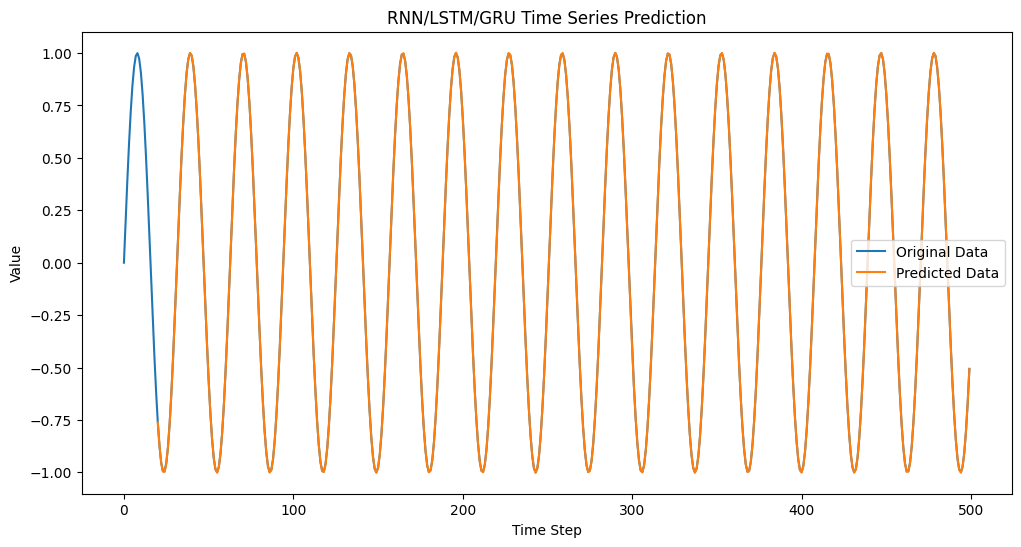

In [42]:
plt.figure(figsize=(12,6))
plt.plot(data_original, label='Original Data')
plt.plot(range(SEQ_LENGTH, len(data_original)), predictions_original, label='Predicted Data')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.title('RNN/LSTM/GRU Time Series Prediction')
plt.legend()
plt.show()